# 시각화

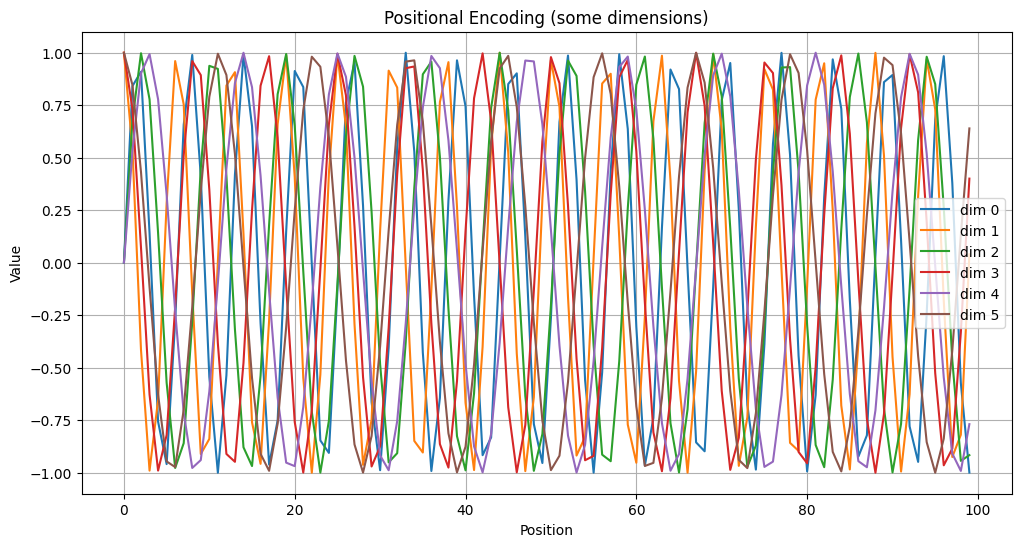

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def get_positional_encoding(seq_len, d_model):
    # (seq_len, d_model) 크기의 위치 인코딩 행렬 생성
    position = np.arange(seq_len)[:, np.newaxis]  # (seq_len, 1)
    div_term = np.exp(np.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))  # (d_model/2,)

    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(position * div_term)  # 짝수 인덱스
    pe[:, 1::2] = np.cos(position * div_term)  # 홀수 인덱스

    return torch.tensor(pe, dtype=torch.float32)  # 텐서로 반환

# 예시: 시퀀스 길이 100, 임베딩 차원 64
pe = get_positional_encoding(seq_len=100, d_model=64)

# 시각화해보자!
plt.figure(figsize=(12, 6))
plt.title("Positional Encoding (some dimensions)")
for i in range(0, 6):  # 앞의 몇 개 차원만 시각화
    plt.plot(pe[:, i], label=f"dim {i}")
plt.xlabel("Position")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()
